# Multimodal Deep Learning for Manufacturing Anomaly Detection
## 멀티모달 딥러닝 기반 제조 공정 이상 탐지 (이미지 + 시계열 센서)

**Dataset**: Future Factories (FF) Dataset - University of South Carolina

**목표**: 이미지 단독, 센서 단독, 멀티모달 융합 모델의 이상 탐지 성능을 비교

| Model | Architecture | Input |
|-------|-------------|-------|
| Model 1 | BiLSTM | 시계열 센서 (22 features) |
| Model 2 | ResNet18 (Transfer Learning) | 카메라 이미지 (224x224) |
| Model 3 | Decision-Level Fusion | 센서 + 이미지 |

---

### Kaggle 실행 시 필요한 Input Datasets
1. `ff-multimodal-csv` - 전처리 완료 CSV (직접 업로드)
2. `ramyharik/ff-2023-12-12-multi-modal-dataset-16` - 이미지 파트 1

Settings > Accelerator > **GPU T4 x2** 로 설정 후 실행

## 1. Setup & Configuration

In [3]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)
from collections import Counter

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda
GPU: Tesla T4


In [4]:
# ============================================================
# 경로 설정 - 자동 탐색
# ============================================================
import glob

KAGGLE_BASE = "/kaggle/input"
ON_KAGGLE = os.path.exists(KAGGLE_BASE)

# CSV 자동 탐색
CSV_PATH = None
if ON_KAGGLE:
    results = glob.glob("/kaggle/input/**/FF_Multimodal.csv", recursive=True)
    if results:
        CSV_PATH = results[0]
        print(f"CSV found: {CSV_PATH}")

if CSV_PATH is None and os.path.exists("data/Multi-modal Dataset/FF_Multimodal.csv"):
    CSV_PATH = "data/Multi-modal Dataset/FF_Multimodal.csv"
    ON_KAGGLE = False

if CSV_PATH is None:
    raise FileNotFoundError("CSV not found. Check input datasets.")

# 이미지 경로 자동 탐색
KAGGLE_IMAGE_ROOTS = glob.glob("/kaggle/input/**/BATCH*", recursive=True)
if KAGGLE_IMAGE_ROOTS:
    # BATCH 폴더의 부모 경로 추출
    IMAGE_BASE_DIRS = list(set(os.path.dirname(p) for p in KAGGLE_IMAGE_ROOTS))
    print(f"Image dirs found: {len(KAGGLE_IMAGE_ROOTS)} BATCH folders")
    print(f"Base dirs: {IMAGE_BASE_DIRS[:3]}")
else:
    IMAGE_BASE_DIRS = []
    print("No image BATCH folders found.")

print(f"ON_KAGGLE: {ON_KAGGLE}")

# ============================================================
# Hyperparameters
# ============================================================
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.5
SEQUENCE_LENGTH = 50
IMAGE_SIZE = 224
TRAIN_RATIO = 0.8

SENSOR_COLUMNS = [
    "I_R01_Gripper_Load", "I_R02_Gripper_Load",
    "I_R03_Gripper_Load", "I_R04_Gripper_Load",
    "I_R01_Gripper_Pot", "I_R02_Gripper_Pot",
    "I_R03_Gripper_Pot", "I_R04_Gripper_Pot",
    "Q_VFD1_Temperature", "Q_VFD2_Temperature",
    "Q_VFD3_Temperature", "Q_VFD4_Temperature",
    "M_Conv1_Speed_mmps", "M_Conv2_Speed_mmps",
    "M_Conv3_Speed_mmps", "M_Conv4_Speed_mmps",
    "M_R01_SJointAngle_Degree", "M_R01_LJointAngle_Degree",
    "M_R01_UJointAngle_Degree",
    "M_R04_SJointAngle_Degree", "M_R04_LJointAngle_Degree",
    "M_R04_UJointAngle_Degree",
]
NUM_SENSOR_FEATURES = len(SENSOR_COLUMNS)
print(f"Sensor features: {NUM_SENSOR_FEATURES}")

CSV found: /kaggle/input/datasets/hyunsungha/ff-multimodal-csv/FF_Multimodal.csv
Image dirs found: 30 BATCH folders
Base dirs: ['/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16']
ON_KAGGLE: True
Sensor features: 22


## 2. Data Loading & EDA

In [5]:
print("Loading CSV...")
df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Raw shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loading CSV...
Raw shape: (166001, 51)
Columns: ['time', 'Q_VFD1_Temperature', 'Q_VFD2_Temperature', 'Q_VFD3_Temperature', 'Q_VFD4_Temperature', 'M_Conv1_Speed_mmps', 'M_Conv2_Speed_mmps', 'M_Conv3_Speed_mmps', 'M_Conv4_Speed_mmps', 'I_R01_Gripper_Pot', 'I_R01_Gripper_Load', 'I_R02_Gripper_Pot', 'I_R02_Gripper_Load', 'I_R03_Gripper_Pot', 'I_R03_Gripper_Load', 'I_R04_Gripper_Pot', 'I_R04_Gripper_Load', 'M_R01_SJointAngle_Degree', 'M_R01_LJointAngle_Degree', 'M_R01_UJointAngle_Degree', 'M_R01_RJointAngle_Degree', 'M_R01_BJointAngle_Degree', 'M_R01_TJointAngle_Degree', 'M_R02_SJointAngle_Degree', 'M_R02_LJointAngle_Degree', 'M_R02_UJointAngle_Degree', 'M_R02_RJointAngle_Degree', 'M_R02_BJointAngle_Degree', 'M_R02_TJointAngle_Degree', 'M_R03_SJointAngle_Degree', 'M_R03_LJointAngle_Degree', 'M_R03_UJointAngle_Degree', 'M_R03_RJointAngle_Degree', 'M_R03_BJointAngle_Degree', 'M_R03_TJointAngle_Degree', 'M_R04_SJointAngle_Degree', 'M_R04_LJointAngle_Degree', 'M_R04_UJointAngle_Degree', 'M_R04_

In [6]:
# 라벨 정리: 소수 클래스 병합, E_STOPPED 제거
label_map = {
    "Normal": "Normal",
    "NoBody1": "NoBody1",
    "NoNose": "NoNose",
    "NoNose,NoBody2": "NoNose_NoBody2",
    "NoNose,NoBody2,NoBody1": "NoNose_NoBody2_NoBody1",
    "NoBody2": "NoBody1",
    "NoBody2,NoBody1": "NoBody1",
}

df = df[df["actual_state"] != "E_STOPPED"].copy()
df["label"] = df["actual_state"].map(label_map)
df = df.dropna(subset=["label"]).reset_index(drop=True)

le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)

print(f"Cleaned shape: {df.shape}")
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"\nLabel distribution:")
print(df["label"].value_counts())

Cleaned shape: (165932, 53)

Classes (5): ['NoBody1', 'NoNose', 'NoNose_NoBody2', 'NoNose_NoBody2_NoBody1', 'Normal']

Label distribution:
label
Normal                    90775
NoNose_NoBody2_NoBody1    26628
NoNose_NoBody2            25206
NoNose                    19307
NoBody1                    4016
Name: count, dtype: int64


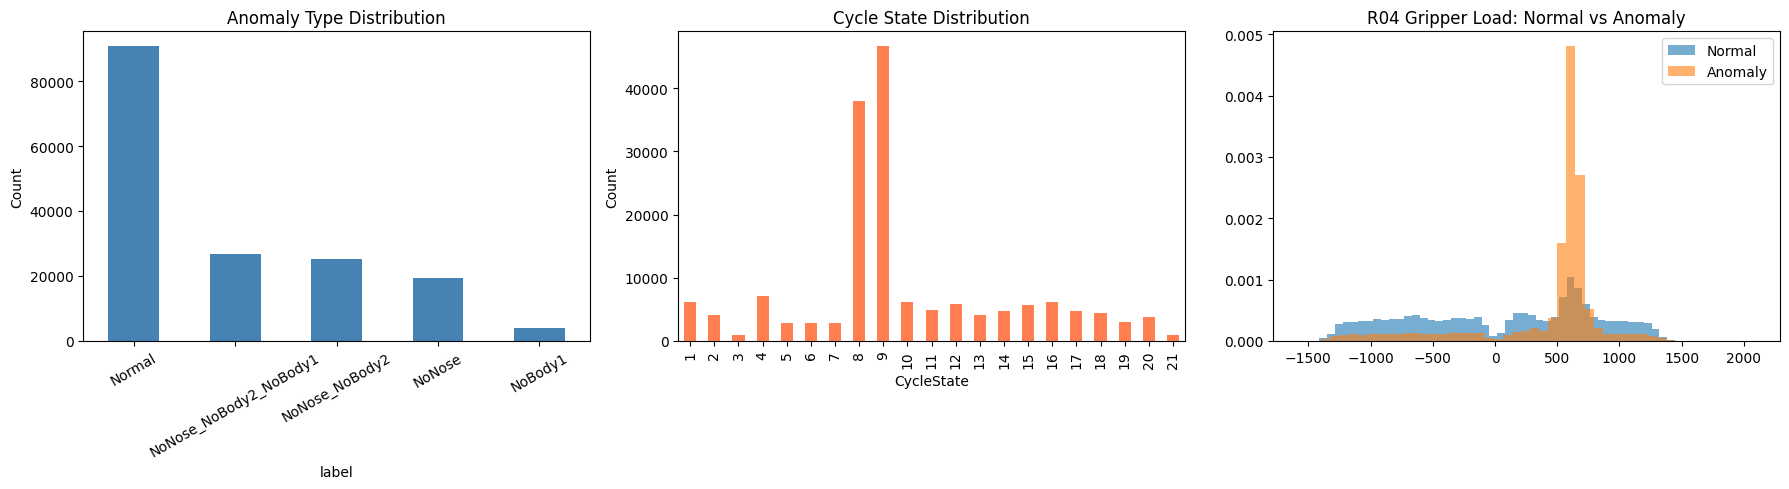

In [7]:
# EDA 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 클래스 분포
df["label"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Anomaly Type Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Cycle State 분포
df["CycleState"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Cycle State Distribution")
axes[1].set_ylabel("Count")

# 센서 분포: Normal vs Anomaly
normal = df[df["label"] == "Normal"]["I_R04_Gripper_Load"]
anomaly = df[df["label"] != "Normal"]["I_R04_Gripper_Load"]
axes[2].hist(normal, bins=50, alpha=0.6, label="Normal", density=True)
axes[2].hist(anomaly, bins=50, alpha=0.6, label="Anomaly", density=True)
axes[2].set_title("R04 Gripper Load: Normal vs Anomaly")
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Preprocessing

In [8]:
# 센서 정규화
scaler = StandardScaler()
df[SENSOR_COLUMNS] = scaler.fit_transform(df[SENSOR_COLUMNS])

# Cycle-wise train/test split (data leakage 방지)
cycles = df["Cycle_Count_New"].unique()
cycle_has_anomaly = df.groupby("Cycle_Count_New")["label"].apply(
    lambda x: (x != "Normal").any()
).astype(int)

train_cycles, test_cycles = train_test_split(
    cycles, train_size=TRAIN_RATIO, random_state=SEED,
    stratify=[cycle_has_anomaly[c] for c in cycles],
)

train_df = df[df["Cycle_Count_New"].isin(train_cycles)].reset_index(drop=True)
test_df = df[df["Cycle_Count_New"].isin(test_cycles)].reset_index(drop=True)

print(f"Train: {len(train_df)} samples ({len(train_cycles)} cycles)")
print(f"Test:  {len(test_df)} samples ({len(test_cycles)} cycles)")
print(f"\nTrain labels:\n{train_df['label'].value_counts()}")
print(f"\nTest labels:\n{test_df['label'].value_counts()}")

Train: 132950 samples (228 cycles)
Test:  32982 samples (57 cycles)

Train labels:
label
Normal                    73230
NoNose_NoBody2_NoBody1    22146
NoNose_NoBody2            20262
NoNose                    13987
NoBody1                    3325
Name: count, dtype: int64

Test labels:
label
Normal                    17545
NoNose                     5320
NoNose_NoBody2             4944
NoNose_NoBody2_NoBody1     4482
NoBody1                     691
Name: count, dtype: int64


In [9]:
# 시계열 시퀀스 생성 (Sliding Window, cycle 단위)
def create_sequences_by_cycle(data_df, sensor_cols, seq_len):
    """같은 cycle 안에서만 sliding window 시퀀스를 만든다."""
    X_list, y_list = [], []
    for cycle_id, group in data_df.groupby("Cycle_Count_New"):
        values = group[sensor_cols].values.astype(np.float32)
        labels = group["label_encoded"].values
        if len(values) < seq_len:
            continue
        for i in range(len(values) - seq_len):
            X_list.append(values[i:i + seq_len])
            y_list.append(labels[i + seq_len])
    return np.array(X_list), np.array(y_list)

print("Creating sequences...")
X_train_seq, y_train_seq = create_sequences_by_cycle(train_df, SENSOR_COLUMNS, SEQUENCE_LENGTH)
X_test_seq, y_test_seq = create_sequences_by_cycle(test_df, SENSOR_COLUMNS, SEQUENCE_LENGTH)
print(f"Train: {X_train_seq.shape}  Test: {X_test_seq.shape}")

# 클래스 가중치 (불균형 처리)
counter = Counter(y_train_seq)
total = len(y_train_seq)
class_weights = torch.FloatTensor([
    total / (NUM_CLASSES * counter.get(i, 1)) for i in range(NUM_CLASSES)
])
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
print(f"\nClass weights: {class_weights.tolist()}")

Creating sequences...
Train: (121550, 50, 22)  Test: (30132, 50, 22)

Class weights: [3.4095005989074707, 0.6262698173522949, 0.43077296018600464, 0.3941263258457184, 0.1393299102783203]


## 4. Image Path Resolution

In [10]:
import glob

# 이미지 BATCH 폴더의 부모 디렉토리 자동 탐색
KAGGLE_IMAGE_ROOTS = glob.glob("/kaggle/input/**/BATCH*", recursive=True)
IMAGE_BASE_DIRS = list(set(os.path.dirname(p) for p in KAGGLE_IMAGE_ROOTS))
print(f"BATCH folders found: {len(KAGGLE_IMAGE_ROOTS)}")
print(f"Base directories: {IMAGE_BASE_DIRS}")


def find_image_path(relative_path):
    """
    CSV 경로 'Dataset/BATCH1000/000000_0.png' 를
    Kaggle 절대 경로로 변환
    """
    if not ON_KAGGLE or not IMAGE_BASE_DIRS:
        return None

    # 'Dataset/' 접두사 제거
    rel = relative_path
    if rel.startswith("Dataset/"):
        rel = rel[len("Dataset/"):]

    # 각 base dir에서 탐색
    for base_dir in IMAGE_BASE_DIRS:
        candidate = os.path.join(base_dir, rel)
        if os.path.exists(candidate):
            return candidate
    return None


# Cycle state 4, 9만 필터 (로켓 부품이 보이는 상태)
df_image = df[df["CycleState"].isin([4, 9])].copy()
print(f"\nImage-eligible rows (state 4,9): {len(df_image)}")

HAS_IMAGES = False
if ON_KAGGLE:
    # 빠른 테스트: 10개만 매칭 시도
    sample = df_image["Cam1"].head(10).tolist()
    found = sum(1 for p in sample if find_image_path(p) is not None)
    print(f"Sample test: {found}/10 images matched")
    
    if found > 0:
        print("Resolving all image paths...")
        df_image["cam1_path"] = df_image["Cam1"].apply(find_image_path)
        n_found = df_image["cam1_path"].notna().sum()
        print(f"Total found: {n_found} / {len(df_image)}")
        df_image = df_image.dropna(subset=["cam1_path"]).reset_index(drop=True)
        HAS_IMAGES = len(df_image) > 100
        if HAS_IMAGES:
            print(f"Image dataset ready: {len(df_image)} samples")
    else:
        print("Path mismatch. Check IMAGE_BASE_DIRS.")
else:
    print("Local mode: image training skipped.")

print(f"\nHAS_IMAGES = {HAS_IMAGES}")

BATCH folders found: 30
Base directories: ['/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16']

Image-eligible rows (state 4,9): 53881
Sample test: 10/10 images matched
Resolving all image paths...
Total found: 9542 / 53881
Image dataset ready: 9542 samples

HAS_IMAGES = True


## 5. Dataset & DataLoader Classes

In [11]:
class SensorSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.X = torch.FloatTensor(sequences)
        self.y = torch.LongTensor(labels)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class ImageAnomalyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = torch.LongTensor(labels)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        try:
            image = Image.open(self.image_paths[idx]).convert("RGB")
            if self.transform:
                image = self.transform(image)
        except Exception:
            image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        return image, self.labels[idx]


class MultimodalDataset(Dataset):
    def __init__(self, sequences, image_paths, labels, transform=None):
        self.X_seq = torch.FloatTensor(sequences)
        self.image_paths = image_paths
        self.labels = torch.LongTensor(labels)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        seq = self.X_seq[idx]
        path = self.image_paths[idx]
        has_image = False
        if path and os.path.exists(str(path)):
            try:
                image = Image.open(path).convert("RGB")
                if self.transform:
                    image = self.transform(image)
                has_image = True
            except Exception:
                image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        else:
            image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        return seq, image, self.labels[idx], has_image


# Image transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("Dataset classes defined.")

Dataset classes defined.


## 6. Model Definitions

In [12]:
# ============================================================
# Model 1: Sensor-Only (BiLSTM)
# ============================================================
class SensorLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2,
                 num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        hidden = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.classifier(hidden)

    def extract_features(self, x):
        _, (h_n, _) = self.lstm(x)
        return torch.cat([h_n[-2], h_n[-1]], dim=1)


# ============================================================
# Model 2: Image-Only (ResNet18 + Transfer Learning)
# ============================================================
class ImageResNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        feat_dim = self.backbone.fc.in_features  # 512
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

    def extract_features(self, x):
        return self.backbone(x)


# ============================================================
# Model 3: Decision-Level Fusion (Sensor + Image)
# ============================================================
class MultimodalFusion(nn.Module):
    """
    [Image]  -> ResNet18 (frozen) -> f_img   (512)
    [Sensor] -> BiLSTM             -> f_sensor (256)
                                       |
                                z = concat (768)
                                       |
                                  FC -> class
    """
    def __init__(self, sensor_input_dim, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        # Image branch (frozen pretrained)
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        img_feat_dim = resnet.fc.in_features  # 512
        resnet.fc = nn.Identity()
        self.image_encoder = resnet
        for p in self.image_encoder.parameters():
            p.requires_grad = False

        # Sensor branch
        self.sensor_lstm = nn.LSTM(
            sensor_input_dim, 128, 2,
            batch_first=True, dropout=dropout, bidirectional=True,
        )
        sensor_feat_dim = 256  # 128*2

        # Fusion head
        self.fusion_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(img_feat_dim + sensor_feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, sensor_seq, images, has_image=None):
        _, (h_n, _) = self.sensor_lstm(sensor_seq)
        f_sensor = torch.cat([h_n[-2], h_n[-1]], dim=1)

        with torch.no_grad():
            f_image = self.image_encoder(images)

        if has_image is not None:
            mask = has_image.float().unsqueeze(1)
            f_image = f_image * mask

        z = torch.cat([f_image, f_sensor], dim=1)
        return self.fusion_head(z)


print("Models defined.")

Models defined.


## 7. Training & Evaluation Functions

In [13]:
def train_epoch(model, loader, criterion, optimizer, model_type):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        if model_type == "fusion":
            sensor, images, y, has_img = batch
            sensor, images = sensor.to(DEVICE), images.to(DEVICE)
            y, has_img = y.to(DEVICE), has_img.to(DEVICE)
            logits = model(sensor, images, has_img)
        else:
            X, y = batch
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)

        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_model(model, loader, criterion, model_type):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        if model_type == "fusion":
            sensor, images, y, has_img = batch
            sensor, images = sensor.to(DEVICE), images.to(DEVICE)
            y, has_img = y.to(DEVICE), has_img.to(DEVICE)
            logits = model(sensor, images, has_img)
        else:
            X, y = batch
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)

        total_loss += criterion(logits, y).item() * y.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    preds, labels = np.array(all_preds), np.array(all_labels)
    return {
        "loss": total_loss / len(labels),
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted", zero_division=0),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall": recall_score(labels, preds, average="weighted", zero_division=0),
        "preds": preds, "labels": labels,
    }


def run_training(model, train_loader, test_loader, model_type, model_name,
                 epochs=EPOCHS, custom_class_weights=None):
    weights = custom_class_weights if custom_class_weights is not None else class_weights
    criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_f1, patience_count = 0, 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_f1": []}

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f" {model_name} | Trainable params: {n_params:,}")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, model_type)
        val = evaluate_model(model, test_loader, criterion, model_type)
        scheduler.step(val["loss"])

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val["loss"])
        history["val_f1"].append(val["f1"])

        print(f"Epoch {epoch:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val['loss']:.4f} F1: {val['f1']:.4f} | "
              f"{time.time()-t0:.1f}s")

        if val["f1"] > best_f1:
            best_f1 = val["f1"]
            patience_count = 0
            torch.save(model.state_dict(), f"{model_name}_best.pt")
        else:
            patience_count += 1
            if patience_count >= 10:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load(f"{model_name}_best.pt", weights_only=True))
    final = evaluate_model(model, test_loader, criterion, model_type)

    print(f"\n--- {model_name} Final Results ---")
    print(f"Accuracy:  {final['accuracy']:.4f}")
    print(f"Precision: {final['precision']:.4f}")
    print(f"Recall:    {final['recall']:.4f}")
    print(f"F1-Score:  {final['f1']:.4f}")
    print(classification_report(
        final["labels"], final["preds"],
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES, zero_division=0,
    ))
    return final, history


print("Training functions ready.")

Training functions ready.


## 8. Model 1: Sensor-Only (BiLSTM)

In [14]:
train_sensor_ds = SensorSequenceDataset(X_train_seq, y_train_seq)
test_sensor_ds = SensorSequenceDataset(X_test_seq, y_test_seq)
train_sensor_loader = DataLoader(train_sensor_ds, batch_size=BATCH_SIZE, shuffle=True)
test_sensor_loader = DataLoader(test_sensor_ds, batch_size=BATCH_SIZE)

sensor_model = SensorLSTM(input_dim=NUM_SENSOR_FEATURES).to(DEVICE)
sensor_result, sensor_history = run_training(
    sensor_model, train_sensor_loader, test_sensor_loader,
    model_type="sensor", model_name="sensor_bilstm"
)


 sensor_bilstm | Trainable params: 567,685
Epoch  1/30 | Train Loss: 0.3396 Acc: 0.8768 | Val Loss: 0.3843 F1: 0.9043 | 20.1s
Epoch  2/30 | Train Loss: 0.1948 Acc: 0.9331 | Val Loss: 0.3522 F1: 0.9081 | 18.4s
Epoch  3/30 | Train Loss: 0.1575 Acc: 0.9472 | Val Loss: 0.3732 F1: 0.9079 | 18.6s
Epoch  4/30 | Train Loss: 0.1339 Acc: 0.9554 | Val Loss: 0.3659 F1: 0.9045 | 18.3s
Epoch  5/30 | Train Loss: 0.1148 Acc: 0.9627 | Val Loss: 0.3308 F1: 0.9108 | 18.5s
Epoch  6/30 | Train Loss: 0.0977 Acc: 0.9690 | Val Loss: 0.4298 F1: 0.9053 | 18.5s
Epoch  7/30 | Train Loss: 0.0811 Acc: 0.9748 | Val Loss: 0.4862 F1: 0.8967 | 18.5s
Epoch  8/30 | Train Loss: 0.0716 Acc: 0.9801 | Val Loss: 0.5760 F1: 0.9025 | 18.3s
Epoch  9/30 | Train Loss: 0.0652 Acc: 0.9824 | Val Loss: 0.5823 F1: 0.8939 | 18.4s
Epoch 10/30 | Train Loss: 0.0596 Acc: 0.9850 | Val Loss: 0.4942 F1: 0.9123 | 18.4s
Epoch 11/30 | Train Loss: 0.0577 Acc: 0.9857 | Val Loss: 0.5744 F1: 0.9025 | 18.4s
Epoch 12/30 | Train Loss: 0.0288 Acc: 0.993

## 9. Model 2: Image-Only (ResNet18)

In [15]:
if HAS_IMAGES:
    df_img_train = df_image[df_image["Cycle_Count_New"].isin(train_cycles)].reset_index(drop=True)
    df_img_test = df_image[df_image["Cycle_Count_New"].isin(test_cycles)].reset_index(drop=True)

    train_img_ds = ImageAnomalyDataset(
        df_img_train["cam1_path"].tolist(),
        df_img_train["label_encoded"].values,
        transform=train_transform,
    )
    test_img_ds = ImageAnomalyDataset(
        df_img_test["cam1_path"].tolist(),
        df_img_test["label_encoded"].values,
        transform=test_transform,
    )
    train_img_loader = DataLoader(train_img_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_img_loader = DataLoader(test_img_ds, batch_size=BATCH_SIZE, num_workers=2)

    # 이미지 데이터셋 전용 class weight 계산 (이게 핵심)
    img_train_labels = df_img_train["label_encoded"].values
    img_counter = Counter(img_train_labels)
    img_total = sum(img_counter.values())
    img_class_weights = torch.FloatTensor([
        img_total / (NUM_CLASSES * img_counter.get(i, 1)) for i in range(NUM_CLASSES)
    ])
    img_class_weights = img_class_weights / img_class_weights.sum() * NUM_CLASSES
    print(f"이미지 클래스 분포: {dict(img_counter)}")
    print(f"이미지 전용 class weights: {img_class_weights.tolist()}")

    image_model = ImageResNet().to(DEVICE)
    image_result, image_history = run_training(
        image_model, train_img_loader, test_img_loader,
        model_type="image", model_name="image_resnet18",
        custom_class_weights=img_class_weights,
    )
else:
    print("[SKIP] No image data. Add Kaggle image dataset as input to enable.")
    image_result, image_history = None, None

이미지 클래스 분포: {np.int64(4): 1141, np.int64(1): 4245, np.int64(2): 1810}
이미지 전용 class weights: [2.4979212284088135, 0.0005884384736418724, 0.0013800669694319367, 2.4979212284088135, 0.002189238555729389]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]



 image_resnet18 | Trainable params: 11,242,821
Epoch  1/30 | Train Loss: 1.1376 Acc: 0.3344 | Val Loss: 1.1825 F1: 0.0355 | 189.8s
Epoch  2/30 | Train Loss: 1.1094 Acc: 0.3546 | Val Loss: 1.0916 F1: 0.0355 | 134.1s
Epoch  3/30 | Train Loss: 1.1044 Acc: 0.3531 | Val Loss: 1.0896 F1: 0.0305 | 132.8s
Epoch  4/30 | Train Loss: 1.1051 Acc: 0.3243 | Val Loss: 1.0976 F1: 0.0355 | 132.9s
Epoch  5/30 | Train Loss: 1.1044 Acc: 0.3360 | Val Loss: 1.0981 F1: 0.0305 | 132.2s
Epoch  6/30 | Train Loss: 1.1023 Acc: 0.3528 | Val Loss: 1.0938 F1: 0.6112 | 131.7s
Epoch  7/30 | Train Loss: 1.1018 Acc: 0.3804 | Val Loss: 1.1128 F1: 0.0355 | 133.6s
Epoch  8/30 | Train Loss: 1.1011 Acc: 0.3298 | Val Loss: 1.1255 F1: 0.0305 | 134.9s
Epoch  9/30 | Train Loss: 1.1023 Acc: 0.3406 | Val Loss: 1.0721 F1: 0.6112 | 134.7s
Epoch 10/30 | Train Loss: 1.1008 Acc: 0.4016 | Val Loss: 1.0804 F1: 0.6112 | 133.1s
Epoch 11/30 | Train Loss: 1.0991 Acc: 0.3387 | Val Loss: 1.0712 F1: 0.3031 | 133.0s
Epoch 12/30 | Train Loss: 1.

## 10. Model 3: Multimodal Fusion (Sensor + Image)

In [16]:
if HAS_IMAGES:
    # 멀티모달 데이터 생성: cycle state 4,9 시점의 센서 시퀀스 + 이미지
    def create_multimodal_data(data_df, img_df, sensor_cols, seq_len):
        # img_df에서 cam1_path lookup 테이블 생성
        img_lookup = {}
        for _, row in img_df.iterrows():
            key = (row["Cycle_Count_New"], row["CycleState"])
            if key not in img_lookup:
                img_lookup[key] = row["cam1_path"]

        X_seq, img_paths, labels = [], [], []
        for cycle_id, group in data_df.groupby("Cycle_Count_New"):
            values = group[sensor_cols].values.astype(np.float32)
            lbl = group["label_encoded"].values
            states = group["CycleState"].values
            if len(values) < seq_len:
                continue
            for i in range(len(values) - seq_len):
                t = i + seq_len
                if states[t] in [4, 9]:
                    X_seq.append(values[i:i + seq_len])
                    labels.append(lbl[t])
                    path = img_lookup.get((cycle_id, states[t]))
                    img_paths.append(path)
        return np.array(X_seq), img_paths, np.array(labels)

    print("Creating multimodal dataset...")
    X_train_mm, img_train, y_train_mm = create_multimodal_data(
        train_df, df_img_train, SENSOR_COLUMNS, SEQUENCE_LENGTH
    )
    X_test_mm, img_test, y_test_mm = create_multimodal_data(
        test_df, df_img_test, SENSOR_COLUMNS, SEQUENCE_LENGTH
    )
    print(f"Train: {X_train_mm.shape}, images: {sum(1 for p in img_train if p)}")
    print(f"Test:  {X_test_mm.shape}, images: {sum(1 for p in img_test if p)}")

    train_mm_ds = MultimodalDataset(X_train_mm, img_train, y_train_mm, train_transform)
    test_mm_ds = MultimodalDataset(X_test_mm, img_test, y_test_mm, test_transform)
    train_mm_loader = DataLoader(train_mm_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_mm_loader = DataLoader(test_mm_ds, batch_size=BATCH_SIZE, num_workers=2)

    fusion_model = MultimodalFusion(sensor_input_dim=NUM_SENSOR_FEATURES).to(DEVICE)
    fusion_result, fusion_history = run_training(
        fusion_model, train_mm_loader, test_mm_loader,
        model_type="fusion", model_name="fusion_dlf"
    )
else:
    print("[SKIP] No image data. Fusion model requires images.")
    fusion_result, fusion_history = None, None

Creating multimodal dataset...
Train: (39624, 50, 22), images: 6733
Test:  (9521, 50, 22), images: 2161

 fusion_dlf | Trainable params: 749,061
Epoch  1/30 | Train Loss: 0.5480 Acc: 0.7770 | Val Loss: 0.4544 F1: 0.8360 | 153.6s
Epoch  2/30 | Train Loss: 0.3959 Acc: 0.8589 | Val Loss: 0.3698 F1: 0.8815 | 152.9s
Epoch  3/30 | Train Loss: 0.3461 Acc: 0.8815 | Val Loss: 0.4263 F1: 0.8685 | 153.0s
Epoch  4/30 | Train Loss: 0.3081 Acc: 0.9018 | Val Loss: 0.4209 F1: 0.8805 | 152.4s
Epoch  5/30 | Train Loss: 0.2741 Acc: 0.9158 | Val Loss: 0.4348 F1: 0.8777 | 153.7s
Epoch  6/30 | Train Loss: 0.2272 Acc: 0.9343 | Val Loss: 0.4321 F1: 0.8730 | 153.0s
Epoch  7/30 | Train Loss: 0.1841 Acc: 0.9457 | Val Loss: 0.5825 F1: 0.8554 | 153.7s
Epoch  8/30 | Train Loss: 0.1444 Acc: 0.9602 | Val Loss: 0.5509 F1: 0.8824 | 154.1s
Epoch  9/30 | Train Loss: 0.0693 Acc: 0.9816 | Val Loss: 0.8805 F1: 0.8581 | 153.0s
Epoch 10/30 | Train Loss: 0.0600 Acc: 0.9849 | Val Loss: 0.8243 F1: 0.8728 | 153.9s
Epoch 11/30 | T

## 11. Results Comparison

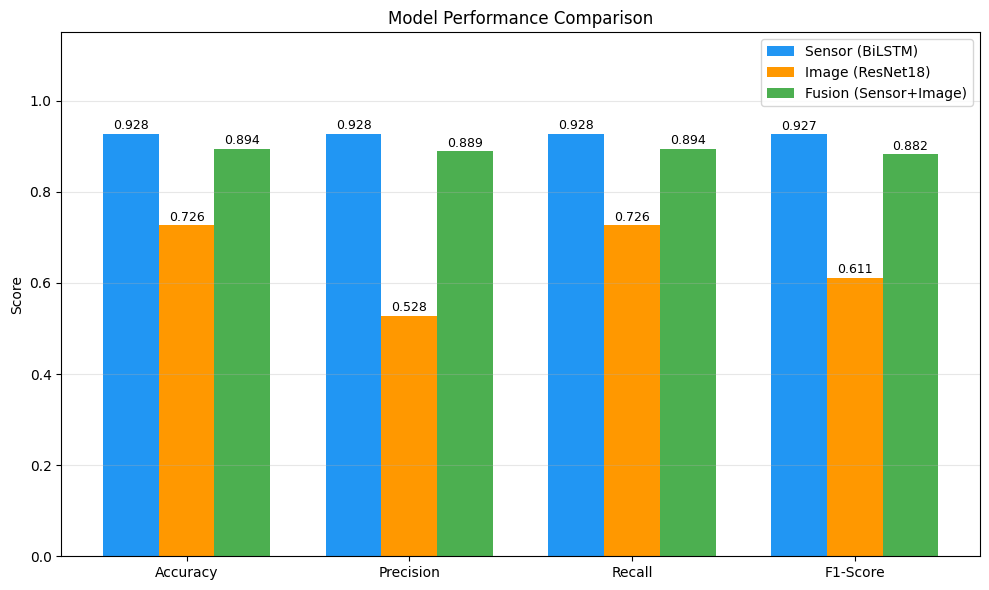

In [17]:
# 결과 수집
all_results = {"Sensor (BiLSTM)": sensor_result}
all_histories = {"Sensor (BiLSTM)": sensor_history}
if image_result:
    all_results["Image (ResNet18)"] = image_result
    all_histories["Image (ResNet18)"] = image_history
if fusion_result:
    all_results["Fusion (Sensor+Image)"] = fusion_result
    all_histories["Fusion (Sensor+Image)"] = fusion_history

# 성능 비교 바 차트
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))
width = 0.25
colors = ["#2196F3", "#FF9800", "#4CAF50"]

for i, (name, res) in enumerate(all_results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                f"{v:.3f}", ha="center", fontsize=9)

ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x + width * (len(all_results)-1)/2)
ax.set_xticklabels(metric_labels)
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

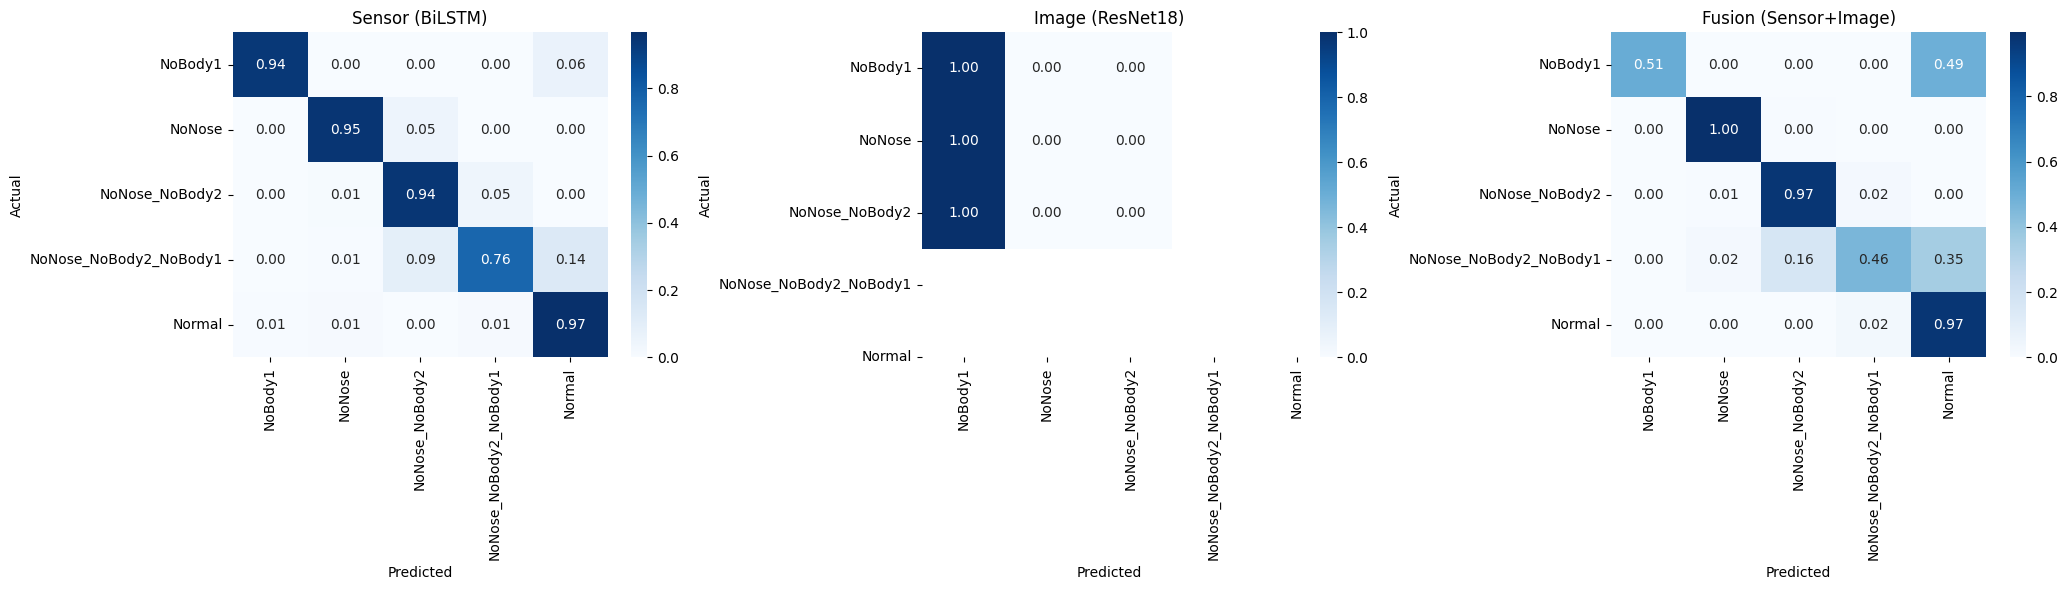

In [18]:
# Confusion Matrix
fig, axes = plt.subplots(1, len(all_results), figsize=(7*len(all_results), 6))
if len(all_results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, all_results.items()):
    cm = confusion_matrix(res["labels"], res["preds"])
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

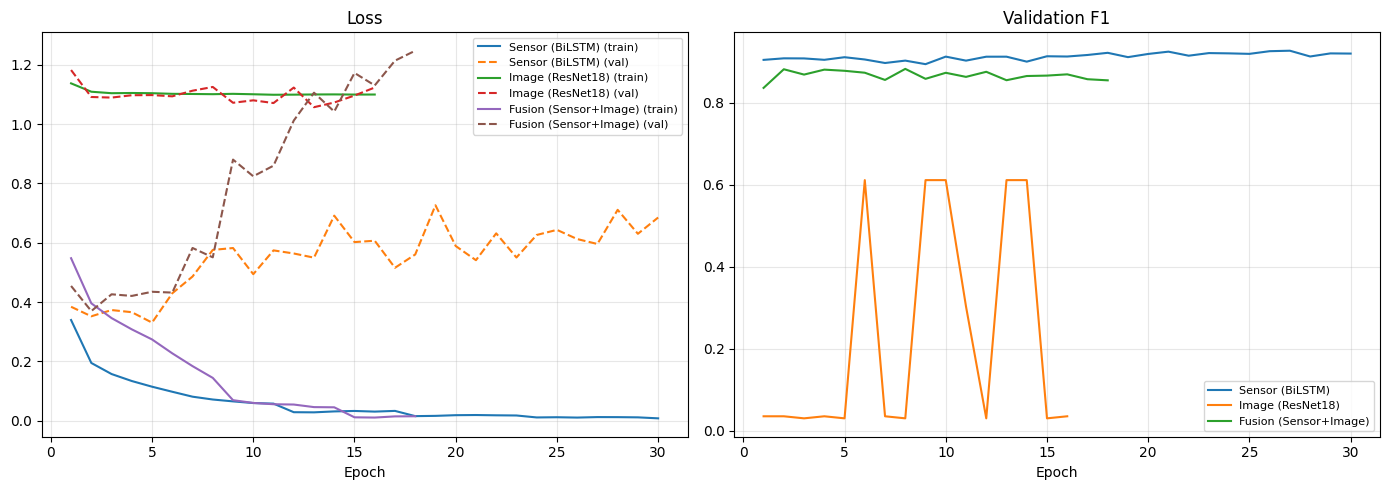

In [19]:
# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in all_histories.items():
    ep = range(1, len(hist["train_loss"])+1)
    axes[0].plot(ep, hist["train_loss"], label=f"{name} (train)")
    axes[0].plot(ep, hist["val_loss"], "--", label=f"{name} (val)")
    axes[1].plot(ep, hist["val_f1"], label=name)

axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_title("Validation F1"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# 최종 요약
print("\n" + "="*70)
print(" FINAL RESULTS SUMMARY")
print("="*70)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*70)
for name, res in all_results.items():
    print(f"{name:<25} {res['accuracy']:>10.4f} {res['precision']:>10.4f} "
          f"{res['recall']:>10.4f} {res['f1']:>10.4f}")
print("="*70)
print("\nDone!")


 FINAL RESULTS SUMMARY
Model                       Accuracy  Precision     Recall         F1
----------------------------------------------------------------------
Sensor (BiLSTM)               0.9276     0.9276     0.9276     0.9267
Image (ResNet18)              0.7263     0.5276     0.7263     0.6112
Fusion (Sensor+Image)         0.8941     0.8891     0.8941     0.8824

Done!


In [21]:
import os
import glob

# Kaggle 데이터셋 전체 구조 확인
base = "/kaggle/input"
print("=== 폴더 구조 ===")
for d in sorted(glob.glob(f"{base}/**/", recursive=True))[:30]:
    print(d)

print("\n=== 파일 확장자별 개수 ===")
exts = {}
for root, dirs, files in os.walk(base):
    for f in files:
        ext = os.path.splitext(f)[1].lower()
        exts[ext] = exts.get(ext, 0) + 1
for ext, count in sorted(exts.items(), key=lambda x: -x[1]):
    print(f"  {ext}: {count}")

print("\n=== PNG 파일 샘플 (있다면) ===")
pngs = glob.glob(f"{base}/**/*.png", recursive=True)[:5]
for p in pngs:
    print(p)
print(f"Total PNG files: {len(glob.glob(f'{base}/**/*.png', recursive=True))}")

print("\n=== JSON 파일 내용 확인 ===")
import json
jsons = glob.glob(f"{base}/**/data_*.json", recursive=True)[:1]
if jsons:
    print(f"Sample JSON: {jsons[0]}")
    with open(jsons[0]) as f:
        data = json.load(f)
    if isinstance(data, dict):
        keys = list(data.keys())[:3]
        print(f"  Type: dict, sample keys: {keys}")
        if keys:
            first_val = data[keys[0]]
            if isinstance(first_val, dict):
                print(f"  Sub-keys: {list(first_val.keys())}")
    elif isinstance(data, list):
        print(f"  Type: list, length: {len(data)}")
        if data:
            print(f"  First item keys: {list(data[0].keys()) if isinstance(data[0], dict) else type(data[0])}")

=== 폴더 구조 ===
/kaggle/input/
/kaggle/input/datasets/
/kaggle/input/datasets/hyunsungha/
/kaggle/input/datasets/hyunsungha/ff-multimodal-csv/
/kaggle/input/datasets/ramyharik/
/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16/
/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16/BATCH1000/
/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16/BATCH10000/
/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16/BATCH11000/
/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16/BATCH12000/
/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16/BATCH13000/
/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16/BATCH14000/
/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16/BATCH15000/
/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16/BATCH16000/
/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16/BATCH17000/
/kaggle/input/dat